# Explorative Datenanalyse

Die TOP100-Listen aller Nationen und die zugehörigen persönlichen Bestleistungen wurden Mitte 2025 auf swimrankings.net gescraped. Eine Zeile entspricht einem Bestleistungs-Eintrag. Die Daten enthalten weder alle Schwimmer noch vollständige Wettkampfbiografien.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from pathlib import Path
from matplotlib.ticker import FuncFormatter
import sys

sys.path.append('../scraper')
from src.utility import parse_time

## 1. Datenübersicht

In [2]:
df = pd.read_csv('../data/raw/athlete_data_master.csv')
df = df.rename(columns={'nactionclub': 'nationclub'})
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 286996 entries, 0 to 286995
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   athlete_id    286996 non-null  int64
 1   athlete_name  286996 non-null  str  
 2   athlete_link  286996 non-null  str  
 3   athlete_date  286996 non-null  str  
 4   athlete_code  286996 non-null  str  
 5   nationclub    286870 non-null  str  
 6   gender        286996 non-null  str  
 7   nation        286996 non-null  str  
 8   event         285308 non-null  str  
 9   course        285308 non-null  str  
 10  time          285308 non-null  str  
 11  best_code     285308 non-null  str  
 12  best_date     285308 non-null  str  
 13  city          285179 non-null  str  
 14  best_name     284706 non-null  str  
dtypes: int64(1), str(14)
memory usage: 93.3 MB


In [3]:
df.head(5)

,athlete_id,athlete_name,athlete_link,athlete_date,athlete_code,nationclub,gender,nation,event,course,time,best_code,best_date,city,best_name
0,4849733,"BERNARDINA, Seggio",https://www.swimrankings.net/index.php?page=at...,1999,AHO,AHO - Netherlands Antilles,male,AHO - Netherlands Antilles,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4849734,"BURNLEY, Mark",https://www.swimrankings.net/index.php?page=at...,1996,AHO,AHO - Netherlands Antilles,male,AHO - Netherlands Antilles,50m Freestyle,50m,26.40,496,15 Mar 2014,Plantation (USA),Speedo Champions Series
2,4849734,"BURNLEY, Mark",https://www.swimrankings.net/index.php?page=at...,1996,AHO,AHO - Netherlands Antilles,male,AHO - Netherlands Antilles,100m Freestyle,50m,55.76,593,16 Mar 2014,Plantation (USA),Speedo Champions Series
3,4849734,"BURNLEY, Mark",https://www.swimrankings.net/index.php?page=at...,1996,AHO,AHO - Netherlands Antilles,male,AHO - Netherlands Antilles,100m Freestyle,25m,53.54,587,6 Dec 2014,Doha (QAT),FINA: 12th World Short Course ...
4,4849734,"BURNLEY, Mark",https://www.swimrankings.net/index.php?page=at...,1996,AHO,AHO - Netherlands Antilles,male,AHO - Netherlands Antilles,200m Freestyle,50m,2:00.19,611,1 Apr 2013,Kingston (JAM),CARIFTA Championships


## 2. Datenprüfung / Bereinigung

### 2.1 Fehlende Werte

In [4]:
print("Fehlende Werte pro Spalte:")
print(df.isnull().sum())

Fehlende Werte pro Spalte:
athlete_id         0
athlete_name       0
athlete_link       0
athlete_date       0
athlete_code       0
nationclub       126
gender             0
nation             0
event           1688
course          1688
time            1688
best_code       1688
best_date       1688
city            1817
best_name       2290
dtype: int64


In [5]:
# Athleten ohne Bestzeiten
na_athletes = df[df['event'].isnull()].drop_duplicates('athlete_id')
pd.Series({
    'Athleten ohne Bestzeiten': len(na_athletes),
    'davon Detailkopf vorhanden': na_athletes['nationclub'].notna().sum(),
    'davon Detailkopf fehlt': na_athletes['nationclub'].isna().sum(),
    'Anteil an allen Athleten': f"{len(na_athletes) / df['athlete_id'].nunique():.1%}",
})

Athleten ohne Bestzeiten       1687
davon Detailkopf vorhanden     1561
davon Detailkopf fehlt          126
Anteil an allen Athleten      11.4%
dtype: object

In [6]:
# NA-Anteil nach Gruppengrösse (Nation gemäss athlete_code und Geschlecht)
athletes = df.drop_duplicates(['athlete_id', 'gender']).copy()
athletes['event_na'] = athletes['event'].isnull()
athletes['list_size'] = athletes.groupby(['athlete_code', 'gender'])['athlete_id'].transform('size')
athletes['Gruppengrösse'] = pd.cut(athletes['list_size'], bins=[0, 25, 50, 90, 120],
                                 labels=['1–25', '26–50', '51–90', '> 90'])
athletes.groupby('Gruppengrösse', observed=True)['event_na'].agg(Anteil_NA='mean', Athleten='size').round(3)

,Anteil_NA,Athleten
Gruppengrösse,,
1–25,0.391,1608
26–50,0.262,1551
51–90,0.230,1572
> 90,0.029,10118


In [7]:
# Fehlende Wettkampf-Angaben bei gültigen Bestzeiten
df[df['event'].notna()][['city', 'best_name']].isnull().sum() 

city         129
best_name    602
dtype: int64

**1'687 Athleten (11.4 %) haben keine Bestzeiten.** Bei 1'561 ist der Detailkopf vorhanden, bei 126 fehlt er ebenfalls. Letztere gelten als vermutete Scraping-Ausfälle. Fehlende Bestzeiten sind in kleinen Nationengruppen häufiger.

Bei vorhandenen Bestzeiten sind 129 Ortsangaben und 602 Wettkampfnamen leer. Weitere fehlende Wettkampfnamen stehen bereits als `Unknown` oder `UNKNOWN` in der Quelle. Die bisherigen Quellenstichproben bestätigen die untersuchten Sonderfälle:

| Athleten-ID | Befund in der Quelle |
|---|---|
| [5378675](https://www.swimrankings.net/index.php?page=athleteDetail&athleteId=5378675) | Keine Bestzeiten vorhanden. |
| [4374860](https://www.swimrankings.net/index.php?page=athleteDetail&athleteId=4374860) | Bestzeiten vorhanden, beim Scraping nicht erfasst. |
| [4271225](https://www.swimrankings.net/index.php?page=athleteDetail&athleteId=4271225), [4074321](https://www.swimrankings.net/index.php?page=athleteDetail&athleteId=4074321) | Wettkampfangaben fehlen auch in der Quelle. |

In [8]:
# Vermutete Scraping-Ausfälle: keine Bestzeiten UND kein Detailkopf.
# Pro Nation/Geschlecht zählen wir Athleten
athletes['scrape_failure'] = athletes['event_na'] & athletes['nationclub'].isna()
failures_by_gender = athletes.groupby('gender').agg(
    Athleten=('athlete_id', 'size'),
    Ausfaelle=('scrape_failure', 'sum'),
)
failures_by_gender['Ausfallquote_%'] = (
    100 * failures_by_gender['Ausfaelle'] / failures_by_gender['Athleten']
).round(2)
display(failures_by_gender)

failures_by_nation = athletes.groupby(['athlete_code', 'gender']).agg(
    Athleten=('athlete_id', 'size'),
    Ausfaelle=('scrape_failure', 'sum'),
)
failures_by_nation['Ausfallquote_%'] = (
    100 * failures_by_nation['Ausfaelle'] / failures_by_nation['Athleten']
).round(1)
display(failures_by_nation.loc[failures_by_nation['Ausfaelle'] > 0]
        .sort_values('Ausfallquote_%', ascending=False))

,Athleten,Ausfaelle,Ausfallquote_%
gender,,,
female,6673,122,1.83
male,8176,4,0.05


Athleten  Ausfaelle  Ausfallquote_%
athlete_code gender                                     
HUN          female       101         50            49.5
BRA          female       100         33            33.0
CRO          female       100         19            19.0
LAT          female        96         11            11.5
GER          female       104          4             3.8
ISR          male         100          3             3.0
             female       100          2             2.0
UAE          female        50          1             2.0
CZE          female       100          1             1.0
ROU          female       101          1             1.0
SWE          male          98          1             1.0

Die 126 Ausfälle betreffen 122 Frauen und 4 Männer, besonders Ungarn (50 von 101 Athletinnen), Brasilien (33 von 100) und Kroatien (19 von 100). Dadurch können Länder- und Geschlechtervergleiche verzerrt sein. Die fehlenden Daten konnten wegen Cloudflare nicht nachgescraped werden.

### 2.2 Duplikate

In [9]:
dups = df[df.duplicated(keep=False)].sort_values(['athlete_id', 'event', 'course'])
print(f"Überzählige Zeilen: {df.duplicated().sum()} | betroffene Athleten: {dups['athlete_id'].nunique()}")
dups[['athlete_id', 'athlete_name', 'event', 'course', 'time', 'best_date', 'best_name']].head(6)

Überzählige Zeilen: 134 | betroffene Athleten: 57


,athlete_id,athlete_name,event,course,time,best_date,best_name
99682,4044477,"WEIJDEN van der, Maarten",5000m Freestyle,50m,54:06.88,15 Feb 2008,WK Kwalificatiewedstrijd Open ...
99683,4044477,"WEIJDEN van der, Maarten",5000m Freestyle,50m,54:06.88,15 Feb 2008,WK Kwalificatiewedstrijd Open ...
257736,4060124,"HO, Roanne",100m Breaststroke,50m,1:11.33,27 Jun 2015,Neo Garden 11th S'pore Nats Sw
257737,4060124,"HO, Roanne",100m Breaststroke,50m,1:11.33,27 Jun 2015,Neo Garden 11th S'pore Nats Sw
257729,4060124,"HO, Roanne",50m Freestyle,50m,26.60,26 Jun 2015,Neo Garden 11th S'pore Nats Sw
257730,4060124,"HO, Roanne",50m Freestyle,50m,26.60,26 Jun 2015,Neo Garden 11th S'pore Nats Sw


134 exakte Duplikate werden entfernt. Sie stehen bereits doppelt in der Quelle, beispielsweise bei Athleten-ID 4044477. Ob gleiche Zeiten in Vorlauf und Final oder Erfassungsfehler dahinterstehen, ist unklar.

### 2.3 Bereinigung

Zeilen ohne Bestzeiten und exakte Duplikate werden entfernt. Leerzeichen in Wettkampfname, Ort und Beckenlänge werden vereinheitlicht. Leere Angaben und Varianten von `Unknown` erhalten einheitlich `Unknown`, gekürzte Namen bleiben erhalten. Unbekannte Jahrgänge, Daten, Zeiten (`NT`) und Punkte werden als NA gespeichert.

Zeiten werden in Sekunden umgerechnet, Handzeitnahme bleibt in `manual_timing` markiert. Jahrgang, Datum und Punkte erhalten passende Datentypen.

**Entfernt wird auch die Zeit 55:55.55 über 200 m Brust bei Athleten-ID 5052749.** Sie steht so in der Quelle, ist aber unplausibel und wird als fehlerhafter Eintrag ausgeschlossen.

In [10]:
n_before = len(df)
df = df.dropna(subset=['event']).copy()
for column in ['best_name', 'city', 'course']:
    values = df[column].str.replace(r'\s+', ' ', regex=True).str.strip()
    df[column] = values.mask(
        values.str.casefold().isin(['', 'unknown']), 'Unknown'
    ).fillna('Unknown')

df['athlete_date'] = pd.to_numeric(df['athlete_date'], errors='coerce').astype('Int64')  # '??' -> NA
df['best_date'] = pd.to_datetime(df['best_date'], format='%d %b %Y', errors='coerce')  # '???' -> NaT
df['manual_timing'] = df['time'].str.endswith('M')  # 'M' = handgestoppt
df['time'] = df['time'].replace('NT', pd.NA).map(parse_time, na_action='ignore').astype('Float64')  # '1:52.04' -> 112.04 s, 'NT' -> NA
df['best_code'] = pd.to_numeric(df['best_code'], errors='coerce').astype('Int64')  # '-' -> NA
df = df.rename(columns={'time': 'time_s', 'best_code': 'points'})
df = df.drop_duplicates()

# Bestätigter unplausibler Quellenwert: 55:55.55 über 200 m Brust.
invalid_time = (
    df['athlete_id'].eq(5052749)
    & df['event'].eq('200m Breaststroke')
    & df['course'].eq('50m')
    & df['time_s'].eq(3355.55).fillna(False)
)
df = df.loc[~invalid_time].copy()
print(f"Zeilen vorher: {n_before:,} | nachher: {len(df):,}")
print("Verbleibende NAs (bewusst):")
print(df.isnull().sum()[lambda s: s > 0])
print('Fehlende Veranstaltungsangaben mit Unknown:')
print(df[['city', 'best_name', 'course']].eq('Unknown').sum())

Zeilen vorher: 286,996 | nachher: 285,173
Verbleibende NAs (bewusst):
athlete_date      236
time_s              1
points          53577
best_date           1
dtype: int64
Fehlende Veranstaltungsangaben mit Unknown:
city         129
best_name    763
course         0
dtype: int64


### 2.4 Spaltenbereinigung

`nationclub` wird in `athlete_nation` und `club` aufgeteilt und anschliessend entfernt. Leere Vereinsangaben bleiben NA.

Die beiden Nationenfelder haben unterschiedliche Bedeutungen:

* `nation` ist die beim Scraping ausgewählte **Länderliste**, über die der Athlet gefunden wurde.
* `athlete_nation` ist die **Nation des Athleten laut Profil** zum Scraping-Zeitpunkt.

Beispiel: Matija Jaukovic (ID 4274157) wurde über die australische Liste gefunden. Sein Profil nennt Montenegro und den Verein Sydney University in Australien. Der Vereinsbezug ist damit eine plausible Erklärung für diesen Fall. Die genauen Auswahlregeln der Listen sind aus den gespeicherten Daten allein nicht ersichtlich.

Bei 215 Athleten unterscheiden sich Listenland und Profilnation, deshalb bleiben beide Felder erhalten. Die Auswertung «Athleten pro Nation» verwendet `athlete_code` und damit die Profilnation.


In [11]:
nation_labels = (
    df['nation'].str.replace(r'\s+', ' ', regex=True).str.strip()
    .drop_duplicates().str.split(' - ', n=1, expand=True)
)
nation_names = dict(zip(nation_labels[0], nation_labels[1]))
nation_names['TUR'] = 'Türkiye'  # Schreibweise im Athletenprofil
df['athlete_nation'] = df['athlete_code'].map(nation_names).astype('string')
assert df['athlete_nation'].notna().all(), 'Unbekannter Nationencode'


def extract_club(value, code, nation_name):
    prefix = f'{code} - {nation_name}'
    if value == prefix:
        return pd.NA
    if value.startswith(prefix + ' '):
        return value[len(prefix):].strip() or pd.NA
    raise ValueError(f'Unbekanntes nationclub-Format: {value!r}')


df['club'] = pd.Series(
    [extract_club(value, code, name)
     for value, code, name in zip(df['nationclub'], df['athlete_code'], df['athlete_nation'])],
    index=df.index,
    dtype='string',
)

df = df.drop(columns=['nationclub'])

### 2.5 Plausibilitätsprüfungen

Geprüft werden Stammdaten, Zeiten, Punkte und Bahnlängen. Das ungefähre Alter ergibt sich aus Ergebnisjahr minus Geburtsjahr.

In [12]:
age_at_result = df['best_date'].dt.year - df['athlete_date']
athlete_fields = ['athlete_name', 'athlete_date', 'athlete_code', 'gender',
                  'athlete_nation', 'club']
inconsistent_athletes = (
    df.groupby('athlete_id')[athlete_fields].nunique(dropna=False).gt(1).any(axis=1)
)
athlete_info = df.drop_duplicates('athlete_id')

display(pd.Series({
    'Exakte Duplikate (Zeilen)': df.duplicated().sum(),
    'Widersprüchliche Stammdaten (Athleten)': inconsistent_athletes.sum(),
    'Zeit <= 0 (Zeilen)': df['time_s'].le(0).sum(),
    'Punkte <= 0 (Zeilen)': df['points'].le(0).sum(),
    'Ergebnis vor Geburtsjahr (Zeilen)': age_at_result.lt(0).sum(),
    'Andere Bahnlänge als 25m/50m (Zeilen)': (~df['course'].isin(['25m', '50m'])).sum(),
    'Keine Vereinsangabe (Athleten)': athlete_info['club'].isna().sum(),
}, name='Anzahl').to_frame())
print(f'Ungefähres Alter bei Bestleistung: {age_at_result.min():.0f} bis {age_at_result.max():.0f} Jahre '
      f'({age_at_result.isna().sum()} Einträge ohne berechenbares Alter).')
print(f'Fehlende Zeiten: {df["time_s"].isna().sum()} | '
      f'Fehlende Punkte: {df["points"].isna().mean():.1%}')

,Anzahl
Exakte Duplikate (Zeilen),0
Widersprüchliche Stammdaten (Athleten),0
Zeit <= 0 (Zeilen),0
Punkte <= 0 (Zeilen),0
Ergebnis vor Geburtsjahr (Zeilen),0
Andere Bahnlänge als 25m/50m (Zeilen),0
Keine Vereinsangabe (Athleten),5115


Ungefähres Alter bei Bestleistung: 6 bis 66 Jahre (237 Einträge ohne berechenbares Alter).
Fehlende Zeiten: 1 | Fehlende Punkte: 18.8%


In [13]:
# Zeiten nur innerhalb derselben Disziplin, Bahnlänge und Geschlechtsgruppe vergleichen.
performance_summary = df.groupby(['event', 'gender', 'course']).agg(
    Eintraege=('athlete_id', 'size'),
    Zeit_min_s=('time_s', 'min'),
    Zeit_median_s=('time_s', 'median'),
    Zeit_max_s=('time_s', 'max'),
    Punkte_min=('points', 'min'),
    Punkte_max=('points', 'max'),
).round(2)
# Einzelne Disziplin anschauen
display(performance_summary.loc['100m Freestyle'])

Eintraege  Zeit_min_s  Zeit_median_s  Zeit_max_s  Punkte_min  \
gender course                                                                 
female 25m          3845       50.25          57.37       88.24         184   
       50m          4678       51.71          58.73      125.57          69   
male   25m          4405       44.84          50.79       94.87         105   
       50m          5598        46.4          52.49       92.25         131   

               Punkte_max  
gender course              
female 25m           1000  
       50m           1000  
male   25m           1000  
       50m           1030

In [14]:
# Fehlende Punkte bei Lap und übrigen Disziplinen.
point_group = df['event'].str.endswith(' Lap').map({
    True: 'Disziplinen mit Lap', False: 'Übrige Disziplinen',
})
points_coverage = df.groupby(point_group.rename('Disziplinart')).agg(
    Eintraege=('points', 'size'),
    Punkte_fehlend=('points', lambda values: values.isna().sum()),
)
display(points_coverage)

,Eintraege,Punkte_fehlend
Disziplinart,,
Disziplinen mit Lap,53019,53019
Übrige Disziplinen,232154,558


Die formalen Prüfungen sind unauffällig. Die Alterswerte von 6 und 66 Jahren wurden geprüft und bestätigt. Bei 5'115 Athleten fehlt die Vereinsangabe.

Die 53'577 fehlenden Punkte betreffen 53'019 Einträge mit dem Zusatz `Lap` und 558 seltene Kombinationen aus Disziplin und Bahnlänge. Die Punkte fehlen bereits in der Quelle.

### 2.6 Speichern

Parquet erhält die Datentypen. Nach dem Speichern wird die Datei erneut eingelesen und mit der bereinigten Tabelle verglichen.

In [15]:
out_path = Path('../data/processed/athlete_data_clean.parquet')
out_path.parent.mkdir(parents=True, exist_ok=True)
df.to_parquet(out_path, index=False)

# Kontrolle
check = pd.read_parquet(out_path)
print(f"Gespeichert: {out_path} ({out_path.stat().st_size / 1e6:.1f} MB, {len(check):,} Zeilen)")
pd.testing.assert_frame_equal(df.reset_index(drop=True), check)

Gespeichert: ../data/processed/athlete_data_clean.parquet (3.7 MB, 285,173 Zeilen)


## 3. Explorative Analyse

Kennzahlen pro Athlet verwenden eine Tabelle mit einer Zeile pro `athlete_id`.

In [16]:
COLOR = 'blue'
plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e5e4e0', 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'axes.edgecolor': '#52514e', 'axes.labelcolor': '#52514e',
    'xtick.color': '#52514e', 'ytick.color': '#52514e',
})

# Eine Zeile pro Athlet
ath = df.drop_duplicates(['athlete_id', 'gender']).copy()
ath['n_bests'] = ath['athlete_id'].map(df.groupby('athlete_id').size())

### 3.1 Überblick

In [17]:
pd.Series({
    'Zeilen (Bestzeiten)': len(df),
    'Athleten': df['athlete_id'].nunique(),
    'Nationen': df['athlete_code'].nunique(),
    'Disziplinen (event)': df['event'].nunique(),
    'Wettkampfnamen (ohne Unknown)': df.loc[df['best_name'] != 'Unknown', 'best_name'].nunique(),
    'Zeitraum Bestzeiten': f"{df['best_date'].min():%d.%m.%Y} bis {df['best_date'].max():%d.%m.%Y}",
})

Zeilen (Bestzeiten)                                 285173
Athleten                                             13162
Nationen                                               182
Disziplinen (event)                                     55
Wettkampfnamen (ohne Unknown)                        18878
Zeitraum Bestzeiten              17.10.1964 bis 08.04.2025
dtype: object

### 3.2 Geschlecht

In [18]:
gender = ath['gender'].value_counts().to_frame('Athleten')
gender['Anteil'] = (gender['Athleten'] / gender['Athleten'].sum()).map('{:.1%}'.format)
gender['Bestzeiten'] = df['gender'].value_counts()
gender

,Athleten,Anteil,Bestzeiten
gender,,,
male,7326,55.7%,151836
female,5836,44.3%,133337


### 3.3 Athleten pro Nation

count    182.0
mean      72.3
std       79.7
min        1.0
25%        6.2
50%       28.0
75%      167.0
max      218.0
dtype: float64


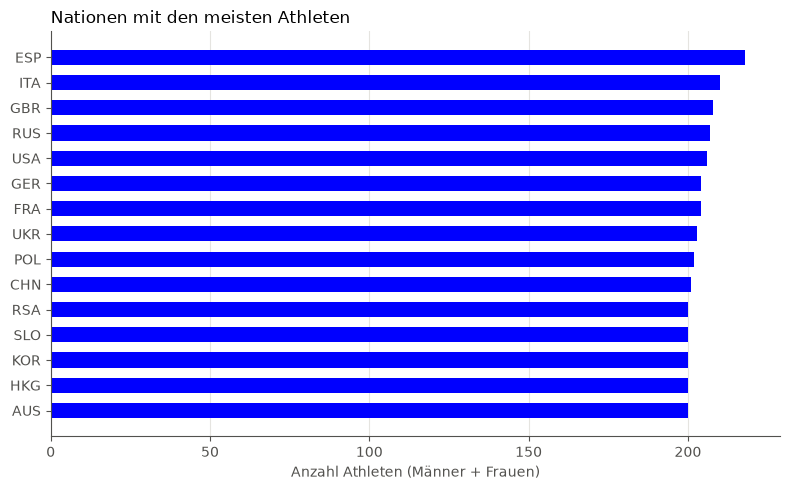

In [19]:
per_nation = ath.groupby('athlete_code').size().sort_values(ascending=False)
print(per_nation.describe().round(1))

top = per_nation.head(15).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.index, top.values, color=COLOR, height=0.6)
ax.set_xlabel('Anzahl Athleten (Männer + Frauen)')
ax.set_title('Nationen mit den meisten Athleten', loc='left')
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

### 3.4 Jahrgang

Athleten ohne Jahrgang: 71
count    13091.0
mean      1995.0
std          9.4
min       1944.0
25%       1989.0
50%       1997.0
75%       2002.0
max       2012.0
Name: athlete_date, dtype: Float64


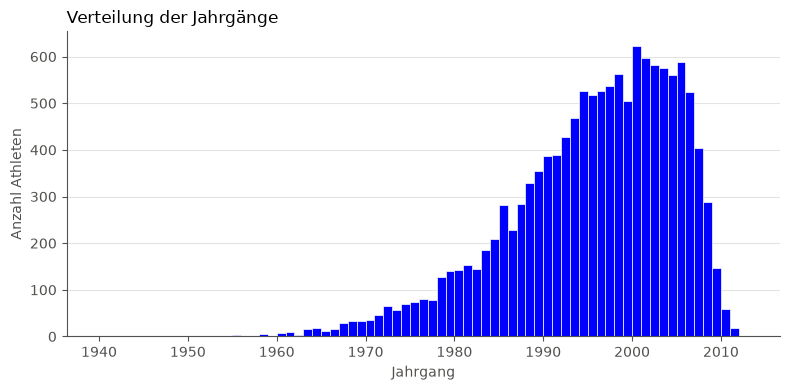

In [20]:
print(f"Athleten ohne Jahrgang: {ath['athlete_date'].isna().sum()}")
print(ath['athlete_date'].describe().round(1))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ath['athlete_date'].dropna(), bins=range(1940, 2014), color=COLOR, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Jahrgang')
ax.set_ylabel('Anzahl Athleten')
ax.set_title('Verteilung der Jahrgänge', loc='left')
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

### 3.5 Bestleistungs-Einträge pro Athlet

Gezählt werden gespeicherte Einträge. Gleiche Bestzeiten können an mehreren Tagen vorkommen.

count    13162.0
mean        21.7
std         14.4
min          1.0
25%          9.0
50%         19.0
75%         34.0
max        100.0
Name: n_bests, dtype: float64


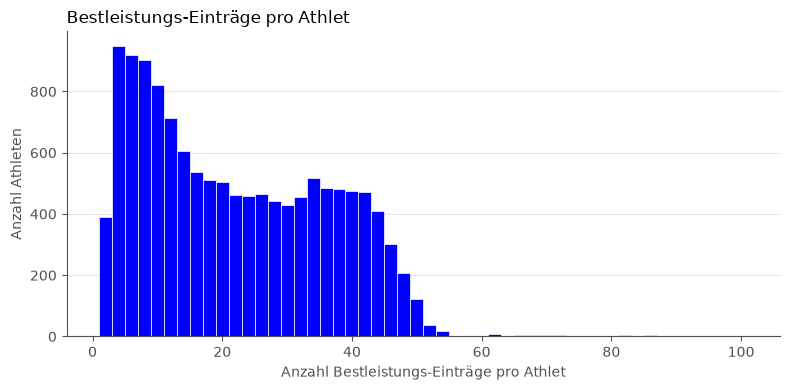

In [21]:
print(ath['n_bests'].describe().round(1))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ath['n_bests'], bins=range(1, 102, 2), color=COLOR, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Anzahl Bestleistungs-Einträge pro Athlet')
ax.set_ylabel('Anzahl Athleten')
ax.set_title('Bestleistungs-Einträge pro Athlet', loc='left')
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

### 3.6 Disziplinen und Bahnlänge

        Bestzeiten
course            
50m         148417
25m         136756


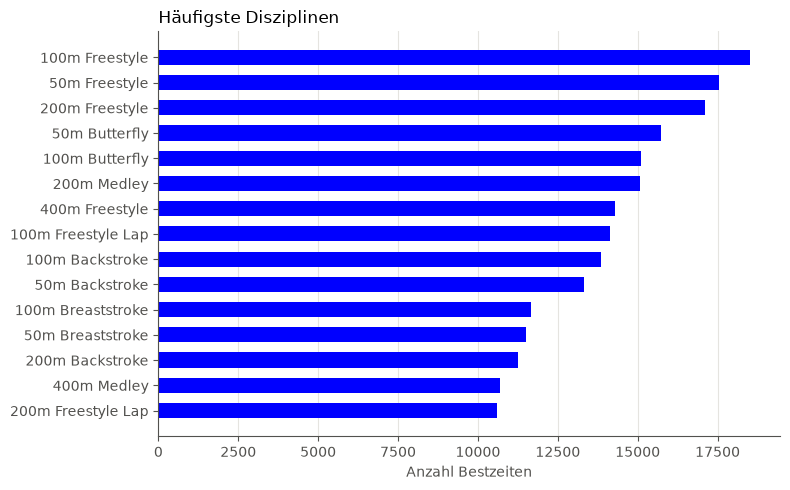

Seltenste Disziplinen:
event
150m Backstroke       4
2500m Freestyle       4
500m Breaststroke     3
1000m Breaststroke    3
150m Medley           1
20000m Freestyle      1
7500m Freestyle       1
1000m Butterfly       1
Name: count, dtype: int64


In [22]:
print(df['course'].value_counts().to_frame('Bestzeiten'))

events = df['event'].value_counts()
top = events.head(15).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.index, top.values, color=COLOR, height=0.6)
ax.set_xlabel('Anzahl Bestzeiten')
ax.set_title('Häufigste Disziplinen', loc='left')
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

print('Seltenste Disziplinen:')
print(events.tail(8))

### 3.7 Wettkampfnamen und Zeitraum

Gekürzte und wiederholte Namen sind keine eindeutigen Wettkampfkennungen. Die Tabelle zählt Einträge je gespeichertem Namen.

Einträge pro Wettkampfname (Median): 3 | Namen mit nur 1 Eintrag: 5583
                                   Bestzeiten
best_name                                    
LEN: European Short Course ...           4571
LEN: European Championships              2757
LEN: European Junior ...                 2197
World Aquatics Championships             1546
FINA: 13th World Championships           1489
New Zealand Short Course ...             1303
Mare Nostrum                             1262
Grand Prix                               1060
FINA: 13th World Short Course ...         950
Irish SC Championships                    933


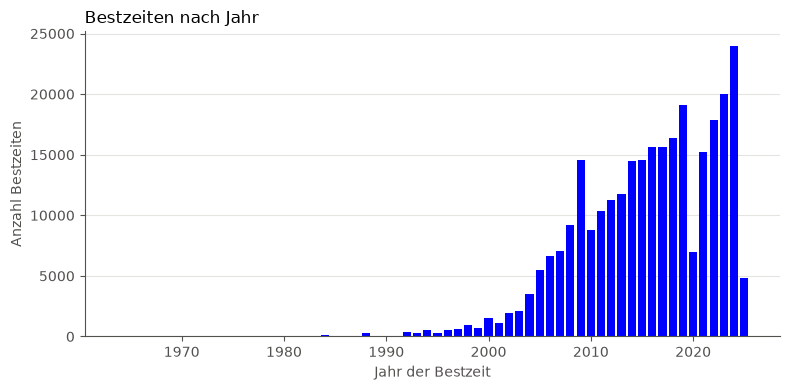

In [23]:
meets = df.loc[df['best_name'] != 'Unknown', 'best_name'].value_counts()
print(f"Einträge pro Wettkampfname (Median): {meets.median():.0f} | Namen mit nur 1 Eintrag: {(meets == 1).sum()}")
print(meets.head(10).to_frame('Bestzeiten'))

years = df['best_date'].dt.year.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(years.index, years.values, color=COLOR, width=0.8)
ax.set_xlabel('Jahr der Bestzeit')
ax.set_ylabel('Anzahl Bestzeiten')
ax.set_title('Bestzeiten nach Jahr', loc='left')
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

### Erkenntnisse

Der bereinigte Datensatz enthält **285'173 Einträge von 13'162 Athleten aus 182 Nationen**. Die Nationen sind sehr unterschiedlich stark vertreten. Die Hälfte umfasst höchstens 28 Athleten. Diese Verteilung spiegelt auch die Auswahl über TOP100-Listen und die Datenabdeckung wider.

Der Anteil beträgt **55.7 % Männer und 44.3 % Frauen**. Die Scraping-Ausfälle betreffen überwiegend Frauen aus wenigen Nationen und beeinflussen diese Zusammensetzung. Bei 5'115 Athleten (38.9 %) fehlt eine Vereinsangabe.

Pro Athlet sind im Median **19 Bestleistungs-Einträge** gespeichert. Diese Zahl beschreibt keine vollständige Wettkampfteilnahme. Fehlende Punkte konzentrieren sich auf Disziplinen mit dem Zusatz `Lap` und seltene Kombinationen aus Strecke und Bahnlänge. Sie sind daher überwiegend durch die Art der erfassten Leistung bedingt.

Die meisten Bestleistungen stammen aus den Jahren ab 2005. Das Jahr 2025 ist wegen des Scraping-Zeitpunkts unvollständig. Der Peak 2009 und der Einbruch 2020 sind sichtbar, ihre Ursachen lassen sich aus der Verteilung allein jedoch nicht nachweisen. Wir vermuten jedoch, dass der Höchststand 2009 mit den damals zugelassenen Hightech-Ganzkörperanzügen und der Einbruch 2020 mit den pandemiebedingten Wettkampfausfällen zusammenhängt. Zudem können gleiche Wettkampfnamen mehrere Austragungen zusammenfassen.

### Abbildung für den Report

Die beiden Verteilungen werden gemeinsam als PDF exportiert. Alle Jahre bleiben enthalten. Ein Eintrag ohne Datum fehlt nur in der zeitlichen Darstellung.

In [24]:
report_dir = Path('../Report/graphics')
report_dir.mkdir(parents=True, exist_ok=True)
years = df['best_date'].dt.year.dropna().astype(int)
per_year = years.value_counts().sort_index()
per_year = per_year.reindex(range(years.min(), years.max() + 1), fill_value=0)
per_athlete = df.groupby('athlete_id').size()

with plt.rc_context({'font.size': 8, 'axes.titlesize': 9,
                     'axes.labelsize': 8, 'xtick.labelsize': 7,
                     'ytick.labelsize': 7, 'pdf.fonttype': 42}):
    fig, axes = plt.subplots(1, 2, figsize=(6.3, 2.65), layout='constrained')
    for ax in axes:
        ax.spines[['top', 'right']].set_visible(False)
        ax.set_axisbelow(True)
        ax.grid(axis='y', color='#e5e4e0', linewidth=0.6)
        ax.grid(axis='x', visible=False)
        ax.yaxis.set_major_formatter(FuncFormatter(
            lambda value, _: f'{value:,.0f}'.replace(',', '\u2009')
        ))

    axes[0].bar(per_year.index, per_year, color='#29658c', width=0.85)
    axes[0].bar(2025, per_year.loc[2025], color='#ad572a', width=0.85,
                label='2025 teilweise erfasst')
    axes[0].set(title='A  Zeitliche Verteilung', xlabel='Jahr der Bestleistung',
                ylabel='Bestleistungseinträge', xlim=(1962, 2027), ylim=(0, 27000),
                xticks=[1965, 1980, 1995, 2010, 2025], yticks=[0, 10000, 20000])
    axes[0].legend(loc='upper left', fontsize=7, frameon=False)

    axes[1].hist(per_athlete, bins=range(1, int(per_athlete.max()) + 2, 2),
                 color='#29658c', edgecolor='white', linewidth=0.35)
    axes[1].axvline(per_athlete.median(), color='#ad572a', linestyle='--',
                    linewidth=1.2, label=f'Median {per_athlete.median():.0f}')
    axes[1].set(title='B  Umfang je Athlet', xlabel='Bestleistungseinträge pro Athlet',
                ylabel='Athleten', xlim=(0, 102), xticks=[0, 20, 40, 60, 80, 100])
    axes[1].legend(loc='upper right', fontsize=7, frameon=False)

    fig.savefig(report_dir / '02_eda_ueberblick.pdf', bbox_inches='tight')
    plt.close(fig)

print('Plot gespeichert.')

Plot gespeichert.
